<img src="Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Santiago Boente

En este trabajo práctico tuvimos como finalidad simular el bloque de cuantización de un ADC de B bits en un rango de $\pm$VF Volts. Esta vez incluyendo la capacidad de muestrear a fs Hertz.

Para realizar esto, tomaremos como parámetros iniciales:
-Frecuencia  f0=fS/N=Δf
-Energía (o varianza) unitaria
-Frecuencia de muestreo fS=1000Hz
-Rango analógico de ±VF=2 Volts

Y para la secuencia de ruido:
-La señal que entra al ADC será sR = s + n. Siendo n la secuencia que simula la interferencia, y s la senoidal descrita anteriormente.
-La potencia del ruido será Pn = kn.Pq W siendo el factor k una escala para la potencia del ruido de cuantización.

-Pq = $\frac{q^2}{12}$

Finalmente usaremos para el primer experimento B = 4bits y kn = 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

fs = 1000
N = 1000
A = np.sqrt(2)
vfs = 2 # Rango de tensión del ADC
B = 4   # Resolución del ADC [bits]
kn = 1  # Factor de escala del ruido analógico


def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
"tt: vector de tiempo , xx: vector de señal"

tt, xx = mi_funcion_sen(A , 0 , fs/N , 0 , N , fs)


q = (vfs) / 2**B # Paso de cuantización
pq = (q**2)/12   # Potencia del ruido de cuantización
Pn = kn*pq       # Potencia del ruido analógico

snr_pn = 10 * np.log10(1/Pn) # SNR respecto al ruido analógico [dB]
ruido_pn = np.random.normal(0 , np.sqrt(Pn) , len(tt)) # Ruido analógico gaussiano de media 0 y desviación estándar sqrt(Pn)


Habiendo ya definido los parámetros iniciales, le añadiremos el ruido a la señal sinusoidal

In [4]:
#señal + ruido analógico (sR = s + n)
xxpn = xx + ruido_pn

Luego recordaremos el rango analógico del ADC al solicitado. Seguido de cuantizar la señal y finalmente calcularemos el error.

In [5]:
# recorte al rango del ADC
xxpn_clip = np.clip(xxpn, -vfs, vfs)

# cuantización
xxq = q * np.round(xxpn_clip / q)

#error
eq = xxq - xxpn_clip

Con todo esto hecho, graficaremos la amplitud de la señal en función del tiempo

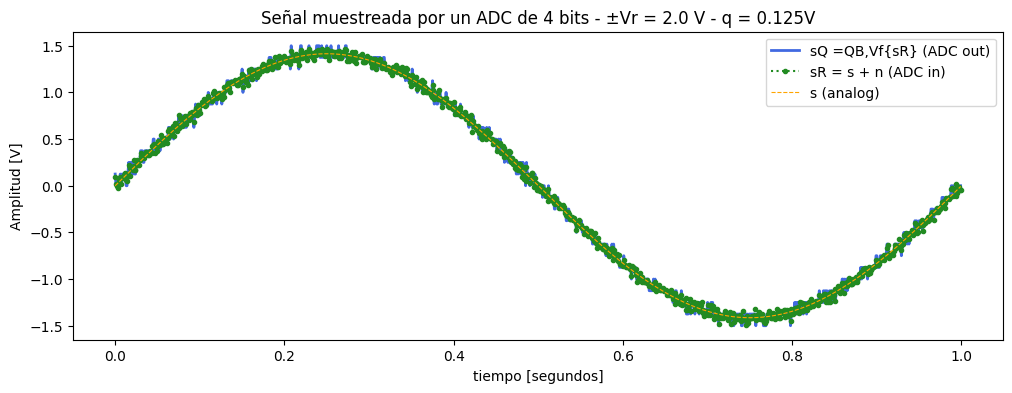

In [15]:
# GRÁFICO 1: Señal en el dominio del tiempo
plt.figure(figsize=(12 , 4))
plt.plot(tt, xxq, color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(tt, xxpn, '.:', color = 'forestgreen',label = 'sR = s + n (ADC in)')
plt.plot(tt, xx, '--', color = 'orange', label = 's (analog)', linewidth = 0.8)
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.show()

Ahora definiremos el espectro de potencia, calculando la FFT de cada señal, normalizandola y posteriormente calculando la densidad de la frecuencia espectral .También generaremos un vector de frecuencias.

In [7]:
# Espectro de potencia
XX = np.fft.fft(xx)/N
XX_mod = 2 * (np.abs(XX)**2)

XXPn = np.fft.fft(xxpn)/N
XXPn_mod = 2 * (np.abs(XXPn)**2)

XXQ = np.fft.fft(xxq)/N
XXQ_mod = 2 * (np.abs(XXQ)**2)

EQ = np.fft.fft(eq)/N
EQ_mod = 2 * (np.abs(EQ)**2)

# Vector de frecuencias
freq = np.fft.fftfreq(len(xx), 1/fs)

A continuación normalizaremos la magnitud a dB y calcularemos el piso teórico digital y analógico. 

In [8]:
# magnitud normalizada en dB
XX_db = 10 * np.log10(XX_mod + 1e-12)
XXPn_db = 10 * np.log10(XXPn_mod + 1e-12)
XXQ_db = 10 * np.log10(XXQ_mod + 1e-12)
EQ_db = 10 * np.log10(EQ_mod + 1e-12)

piso_analog = 10 * np.log10(Pn/(N/2) + 1e-12)
print(f'Piso analógico: {piso_analog:.6f}')
piso_digital = 10 * np.log10(pq/(N/2) + 1e-12)
print(f'Piso digital: {piso_digital:.6f}')

Piso analógico: -55.843311
Piso digital: -55.843311


Con todo esto podremos graficar la densidad de potencia espectral. Para esto limitaremos el rango del vector de frecuencias a N/2 para que no se genere una linea de salto que atraviese todo el gráfico. Usando esto, calcularemos el piso digital y analógico real de la función.

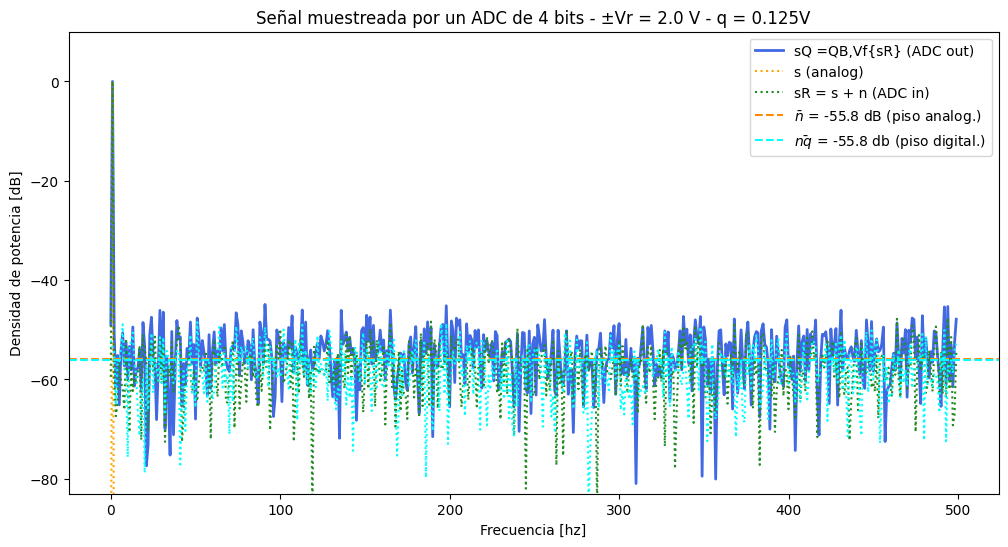

In [16]:
# GRÁFICO 2: Densidad de potencia espectral
plt.figure(figsize=(12, 6))
plt.ylim(-83, 10)

N_half = N // 2
freq_pos = freq[:N_half]

bin_senal = np.argmax(XXPn_mod[:N_half])  # índice del pico
mask_ruido = np.ones(N_half, dtype=bool)
mask_ruido[bin_senal] = False             # excluís el pico

piso_analog_medido  = 10 * np.log10(np.mean(XXPn_mod[:N_half][mask_ruido]) + 1e-12)
piso_digital_medido = 10 * np.log10(np.mean(EQ_mod[:N_half]) + 1e-12)

plt.plot(freq_pos, XXQ_db[:N_half], color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(freq_pos, XX_db[:N_half], ':', color = 'orange', label = 's (analog)', linewidth = 1.5)
plt.plot(freq_pos, XXPn_db[:N_half], ':', color = 'forestgreen',label = 'sR = s + n (ADC in)', linewidth = 1.5)
plt.axhline(piso_analog_medido, color = 'darkorange', linestyle='--', label = f'$\\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)',linewidth = 1.5)
plt.axhline(piso_digital_medido, color = 'cyan', linestyle='--', label = f'$\\bar{{nq}}$ = {piso_digital:.1f} db (piso digital.)', linewidth = 1.5)
plt.plot(freq_pos, EQ_db[:N_half], ':', color='cyan')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("Frecuencia [hz]")
plt.ylabel("Densidad de potencia [dB]")
plt.legend()
plt.show()

En este gráfico podemos observar que el piso analógico y el digital son prácticamente iguales y coinciden con el teórico. Esto se debe a que el kn = 1. Lo que nos da una potencia de ruido y de cuantización iguales.

Para finalizar esta parte del tp graficaremos el histograma del error de cuantización.

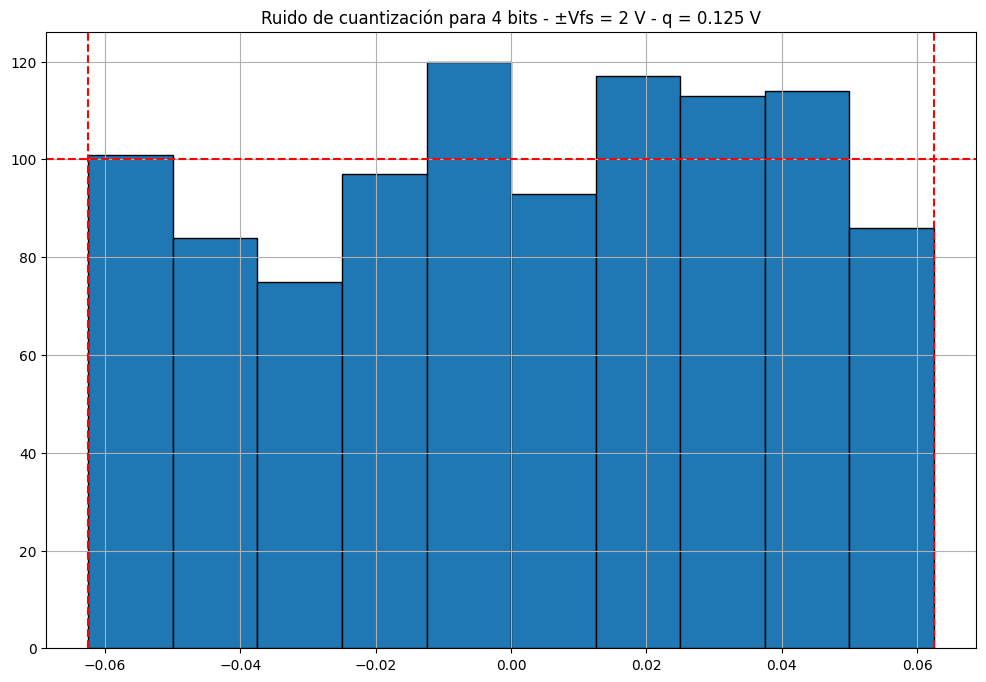

In [17]:
# GRÁFICO 3: Histograma del error de cuantización
plt.figure(figsize=(12,8))

# histograma y guardo datos
counts, bins, _ = plt.hist(eq, bins=10, edgecolor='black')

# centros de cada barra
centros = 0.5 * (bins[:-1] + bins[1:])

# barras dentro del intervalo [-q/2, q/2]
mask = (centros >= -q/2) & (centros <= q/2)

# media de las alturas en ese intervalo
media_intervalo = np.mean(counts[mask])

# líneas rojas
plt.axvline(-q/2, color='r', linestyle='--')
plt.axvline(q/2, color='r', linestyle='--')
plt.axhline(media_intervalo, color='r', linestyle='--')
plt.title(f'Ruido de cuantización para {B} bits - ±Vfs = {vfs} V - q = {q:.3f} V')
plt.grid(True)
plt.show()

Podemos observar que en este histograma los valores no tienen una variación tan amplia debido al kn utilizado.

Para la segunda parte de este tp analizaremos cada una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}
Empezando por 4 bits (la de 4 bits y kn = 1 ya la hicimos)

K = 1/10:

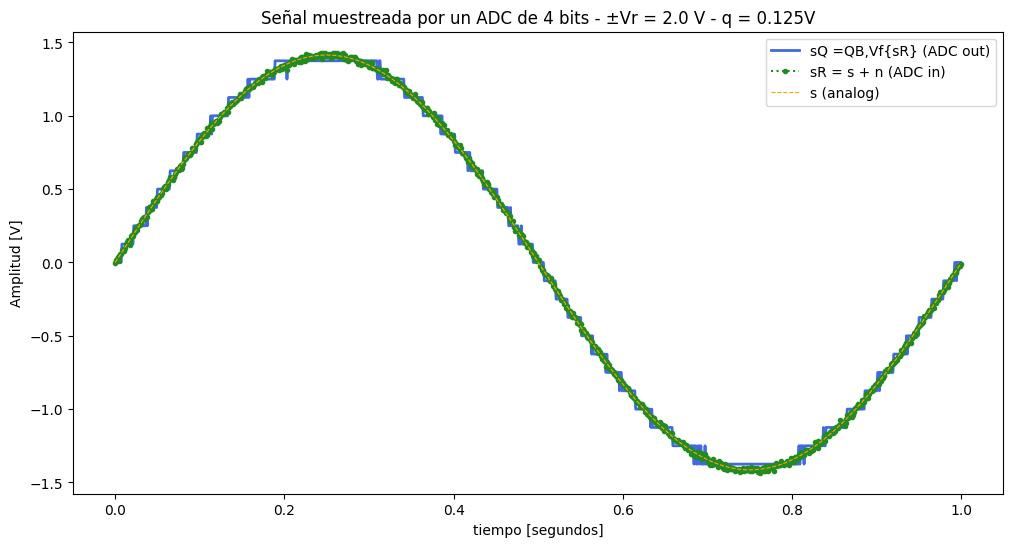

Piso analógico: -65.843296
Piso digital: -55.843311


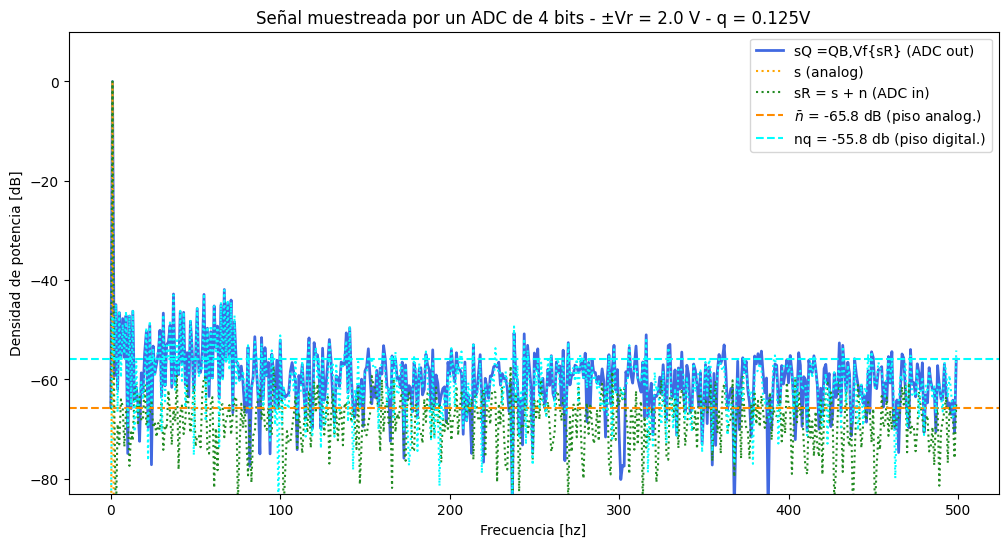

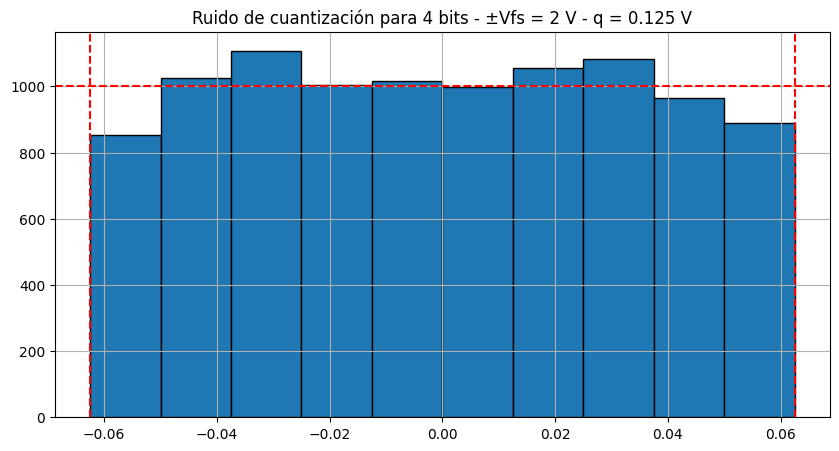

In [22]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

fs = 1000
N = 1000
A = np.sqrt(2)
vfs = 2 # Rango de tensión del ADC
B = 4   # Resolución del ADC [bits]
kn = 1/10  # Factor de escala del ruido analógico


def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
"tt: vector de tiempo , xx: vector de señal"

tt, xx = mi_funcion_sen(A , 0 , 1 , 0 , N , fs)

tt2, xx2 = mi_funcion_sen(A , 0 , 1 , 0 , N*10 , fs)

q = (vfs) / 2**B # Paso de cuantización
pq = (q**2)/12   # Potencia del ruido de cuantización
Pn = kn*pq       # Potencia del ruido analógico

snr_pn = 10 * np.log10(1/Pn) # SNR respecto al ruido analógico [dB]
ruido_pn = np.random.normal(0 , np.sqrt(Pn) , len(tt)) # Ruido analógico gaussiano de media 0 y desviación estándar sqrt(Pn)
ruido_pn2 = np.random.normal(0 , np.sqrt(Pn) , len(tt2))

#señal + ruido analógico (sR = s + n)
xxpn = xx + ruido_pn
xxpn2 = xx2 + ruido_pn2

# recorte al rango del ADC
xxpn_clip = np.clip(xxpn, -vfs, vfs)
xxpn_clip2 = np.clip(xxpn2, -vfs, vfs)

# cuantización
xxq = q * np.round(xxpn_clip / q)
xxq2 = q * np.round(xxpn_clip2 / q)

#error
eq = xxq - xxpn_clip
eq2 = xxq2 - xxpn_clip2

# GRÁFICO 1: Señal en el dominio del tiempo
plt.figure(figsize=(12,6))
plt.plot(tt, xxq, color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(tt, xxpn, '.:', color = 'forestgreen',label = 'sR = s + n (ADC in)')
plt.plot(tt, xx, '--', color = 'orange', label = 's (analog)', linewidth = 0.8)
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.show()

# Espectro de potencia
XX = np.fft.fft(xx)/N
XX_mod = 2 * (np.abs(XX)**2)

XXPn = np.fft.fft(xxpn)/N
XXPn_mod = 2 * (np.abs(XXPn)**2)

XXQ = np.fft.fft(xxq)/N
XXQ_mod = 2 * (np.abs(XXQ)**2)

EQ = np.fft.fft(eq)/N
EQ_mod = 2 * (np.abs(EQ)**2)

# Vector de frecuencias
freq = np.fft.fftfreq(len(xx), 1/fs)

# magnitud normalizada en dB
XX_db = 10 * np.log10(XX_mod + 1e-12)
XXPn_db = 10 * np.log10(XXPn_mod + 1e-12)
XXQ_db = 10 * np.log10(XXQ_mod + 1e-12)
EQ_db = 10 * np.log10(EQ_mod + 1e-12)

piso_analog = 10 * np.log10(Pn/(N/2) + 1e-12)
print(f'Piso analógico: {piso_analog:.6f}')
piso_digital = 10 * np.log10(pq/(N/2) + 1e-12)
print(f'Piso digital: {piso_digital:.6f}')


# GRÁFICO 2: Densidad de potencia espectral
plt.figure(figsize=(12,6))
plt.ylim(-83, 10)

N_half = N // 2
freq_pos = freq[:N_half]

bin_senal = np.argmax(XXPn_mod[:N_half])  # índice del pico
mask_ruido = np.ones(N_half, dtype=bool)
mask_ruido[bin_senal] = False             # excluís el pico

piso_analog_medido  = 10 * np.log10(np.mean(XXPn_mod[:N_half][mask_ruido]) + 1e-12)
piso_digital_medido = 10 * np.log10(np.mean(EQ_mod[:N_half]) + 1e-12)

plt.plot(freq_pos, XXQ_db[:N_half], color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(freq_pos, XX_db[:N_half], ':', color = 'orange', label = 's (analog)', linewidth = 1.5)
plt.plot(freq_pos, XXPn_db[:N_half], ':', color = 'forestgreen',label = 'sR = s + n (ADC in)', linewidth = 1.5)
plt.axhline(piso_analog_medido, color = 'darkorange', linestyle='--', label = f'$\\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)',linewidth = 1.5)
plt.axhline(piso_digital_medido, color = 'cyan', linestyle='--', label = f'nq = {piso_digital:.1f} db (piso digital.)', linewidth = 1.5)
plt.plot(freq_pos, EQ_db[:N_half], ':', color='cyan')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("Frecuencia [hz]")
plt.ylabel("Densidad de potencia [dB]")
plt.legend()
plt.show()

# GRÁFICO 3: Histograma del error de cuantización
plt.figure(figsize=(10,5))

# histograma y guardo datos
counts, bins, _ = plt.hist(eq2, bins=10, edgecolor='black')

# centros de cada barra
centros = 0.5 * (bins[:-1] + bins[1:])

# barras dentro del intervalo [-q/2, q/2]
mask = (centros >= -q/2) & (centros <= q/2)

# media de las alturas en ese intervalo
media_intervalo = np.mean(counts[mask])

# líneas rojas
plt.axvline(-q/2, color='r', linestyle='--')
plt.axvline(q/2, color='r', linestyle='--')
plt.axhline(media_intervalo, color='r', linestyle='--')
plt.title(f'Ruido de cuantización para {B} bits - ±Vfs = {vfs} V - q = {q:.3f} V')
plt.grid(True)
plt.show()


En este caso podemos observar que el piso analógico es bastante menor al digital. Además, en el gráfico del tiempo casi no se distingue el sR del s debido a que el ruido disminuye demasiado. Para apreciar mejor los resultados del histograma aumenté la cantidad de N a 10000 (cambio que se puede apreciar en cada variable que tenga un 2 al final. Lo que obtenemos al hacer ese cambio es que la senoidal recorre los niveles de forma no uniforme, dejándonos un histograma con forma de "U" irregular.

Para k = 1/10 y 8 bits:

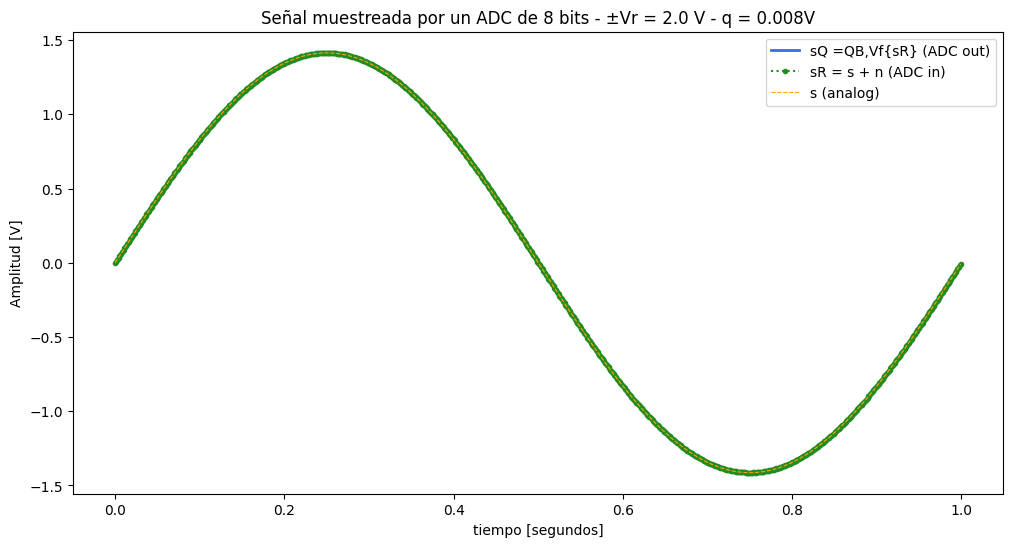

Piso analógico: -89.921445
Piso digital: -79.925285


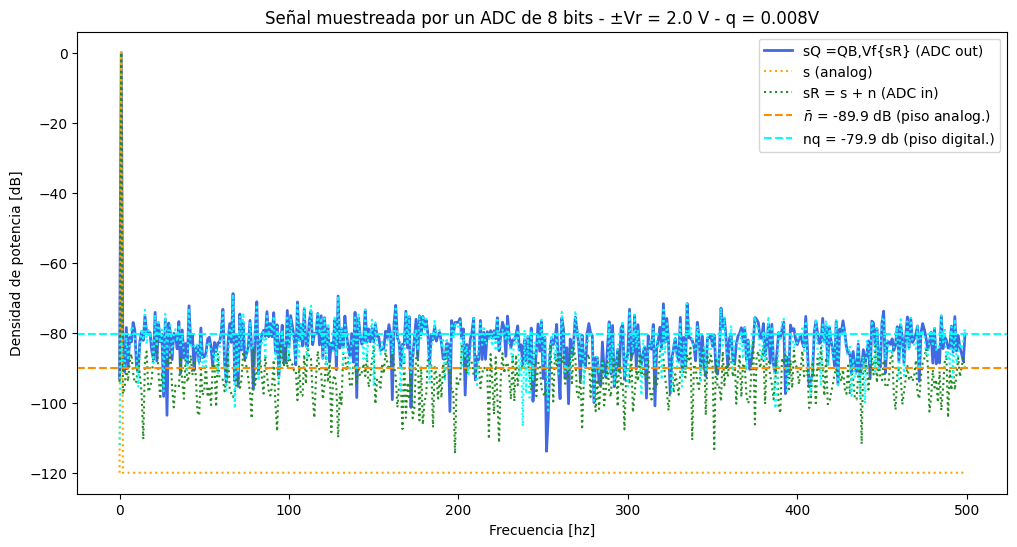

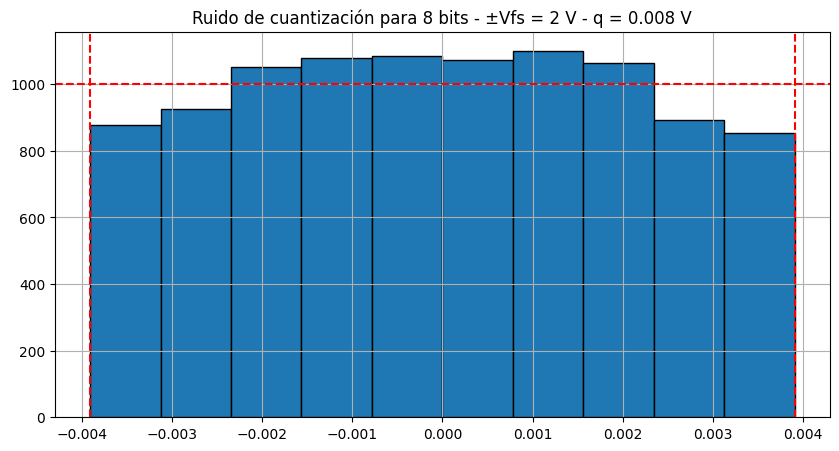

In [24]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

fs = 1000
N = 1000
A = np.sqrt(2)
vfs = 2 # Rango de tensión del ADC
B = 8   # Resolución del ADC [bits]
kn = 1/10  # Factor de escala del ruido analógico


def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
"tt: vector de tiempo , xx: vector de señal"

tt, xx = mi_funcion_sen(A , 0 , 1 , 0 , N , fs)

tt2, xx2 = mi_funcion_sen(A , 0 , 1 , 0 , N*10 , fs)

q = (vfs) / 2**B # Paso de cuantización
pq = (q**2)/12   # Potencia del ruido de cuantización
Pn = kn*pq       # Potencia del ruido analógico

snr_pn = 10 * np.log10(1/Pn) # SNR respecto al ruido analógico [dB]
ruido_pn = np.random.normal(0 , np.sqrt(Pn) , len(tt)) # Ruido analógico gaussiano de media 0 y desviación estándar sqrt(Pn)
ruido_pn2 = np.random.normal(0 , np.sqrt(Pn) , len(tt2))

#señal + ruido analógico (sR = s + n)
xxpn = xx + ruido_pn
xxpn2 = xx2 + ruido_pn2

# recorte al rango del ADC
xxpn_clip = np.clip(xxpn, -vfs, vfs)
xxpn_clip2 = np.clip(xxpn2, -vfs, vfs)

# cuantización
xxq = q * np.round(xxpn_clip / q)
xxq2 = q * np.round(xxpn_clip2 / q)

#error
eq = xxq - xxpn_clip
eq2 = xxq2 - xxpn_clip2

# GRÁFICO 1: Señal en el dominio del tiempo
plt.figure(figsize=(12,6))
plt.plot(tt, xxq, color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(tt, xxpn, '.:', color = 'forestgreen',label = 'sR = s + n (ADC in)')
plt.plot(tt, xx, '--', color = 'orange', label = 's (analog)', linewidth = 0.8)
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.show()

# Espectro de potencia
XX = np.fft.fft(xx)/N
XX_mod = 2 * (np.abs(XX)**2)

XXPn = np.fft.fft(xxpn)/N
XXPn_mod = 2 * (np.abs(XXPn)**2)

XXQ = np.fft.fft(xxq)/N
XXQ_mod = 2 * (np.abs(XXQ)**2)

EQ = np.fft.fft(eq)/N
EQ_mod = 2 * (np.abs(EQ)**2)

# Vector de frecuencias
freq = np.fft.fftfreq(len(xx), 1/fs)

# magnitud normalizada en dB
XX_db = 10 * np.log10(XX_mod + 1e-12)
XXPn_db = 10 * np.log10(XXPn_mod + 1e-12)
XXQ_db = 10 * np.log10(XXQ_mod + 1e-12)
EQ_db = 10 * np.log10(EQ_mod + 1e-12)

piso_analog = 10 * np.log10(Pn/(N/2) + 1e-12)
print(f'Piso analógico: {piso_analog:.6f}')
piso_digital = 10 * np.log10(pq/(N/2) + 1e-12)
print(f'Piso digital: {piso_digital:.6f}')


# GRÁFICO 2: Densidad de potencia espectral
plt.figure(figsize=(12,6))
#plt.ylim(-83, 10)

N_half = N // 2
freq_pos = freq[:N_half]

bin_senal = np.argmax(XXPn_mod[:N_half])  # índice del pico
mask_ruido = np.ones(N_half, dtype=bool)
mask_ruido[bin_senal] = False             # excluís el pico

piso_analog_medido  = 10 * np.log10(np.mean(XXPn_mod[:N_half][mask_ruido]) + 1e-12)
piso_digital_medido = 10 * np.log10(np.mean(EQ_mod[:N_half]) + 1e-12)

plt.plot(freq_pos, XXQ_db[:N_half], color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(freq_pos, XX_db[:N_half], ':', color = 'orange', label = 's (analog)', linewidth = 1.5)
plt.plot(freq_pos, XXPn_db[:N_half], ':', color = 'forestgreen',label = 'sR = s + n (ADC in)', linewidth = 1.5)
plt.axhline(piso_analog_medido, color = 'darkorange', linestyle='--', label = f'$\\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)',linewidth = 1.5)
plt.axhline(piso_digital_medido, color = 'cyan', linestyle='--', label = f'nq = {piso_digital:.1f} db (piso digital.)', linewidth = 1.5)
plt.plot(freq_pos, EQ_db[:N_half], ':', color='cyan')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("Frecuencia [hz]")
plt.ylabel("Densidad de potencia [dB]")
plt.legend()
plt.show()

# GRÁFICO 3: Histograma del error de cuantización
plt.figure(figsize=(10,5))

# histograma y guardo datos
counts, bins, _ = plt.hist(eq2, bins=10, edgecolor='black')

# centros de cada barra
centros = 0.5 * (bins[:-1] + bins[1:])

# barras dentro del intervalo [-q/2, q/2]
mask = (centros >= -q/2) & (centros <= q/2)

# media de las alturas en ese intervalo
media_intervalo = np.mean(counts[mask])

# líneas rojas
plt.axvline(-q/2, color='r', linestyle='--')
plt.axvline(q/2, color='r', linestyle='--')
plt.axhline(media_intervalo, color='r', linestyle='--')
plt.title(f'Ruido de cuantización para {B} bits - ±Vfs = {vfs} V - q = {q:.3f} V')
plt.grid(True)
plt.show()


En este caso podemos observar en el primer gráfico el ruido se percibe todavía menos que antes, lo que tiene muchísimo sentido, además en el segundo gráfico vemos que los pisos analógico y digital bajaron los db considerablemente.

Para k = 1/10 y B = 16:

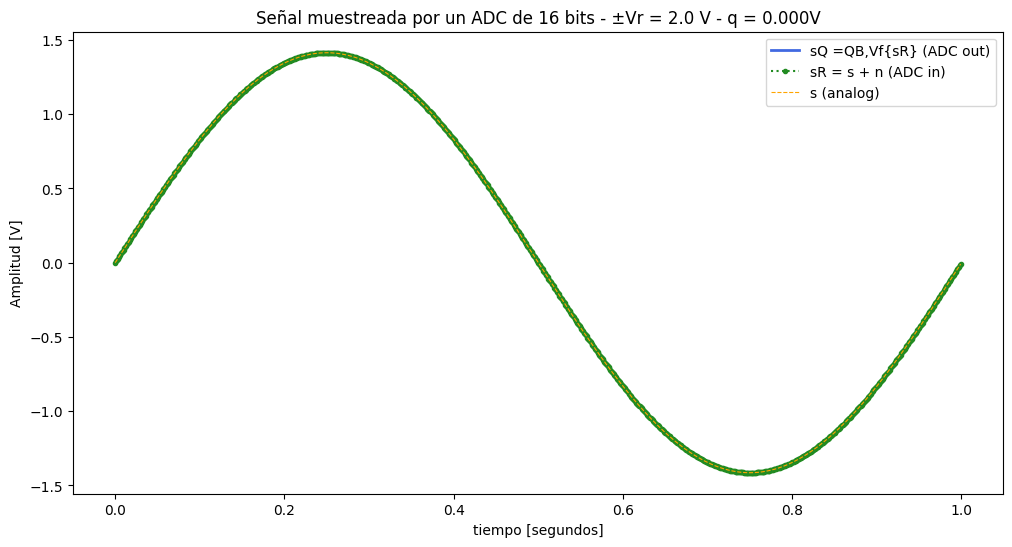

Piso analógico: -119.933106
Piso digital: -119.373351


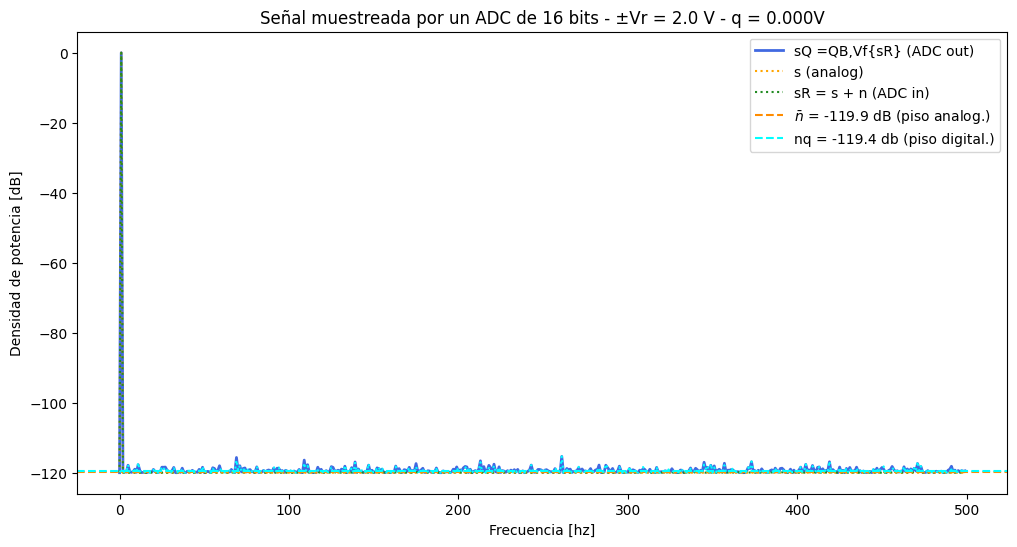

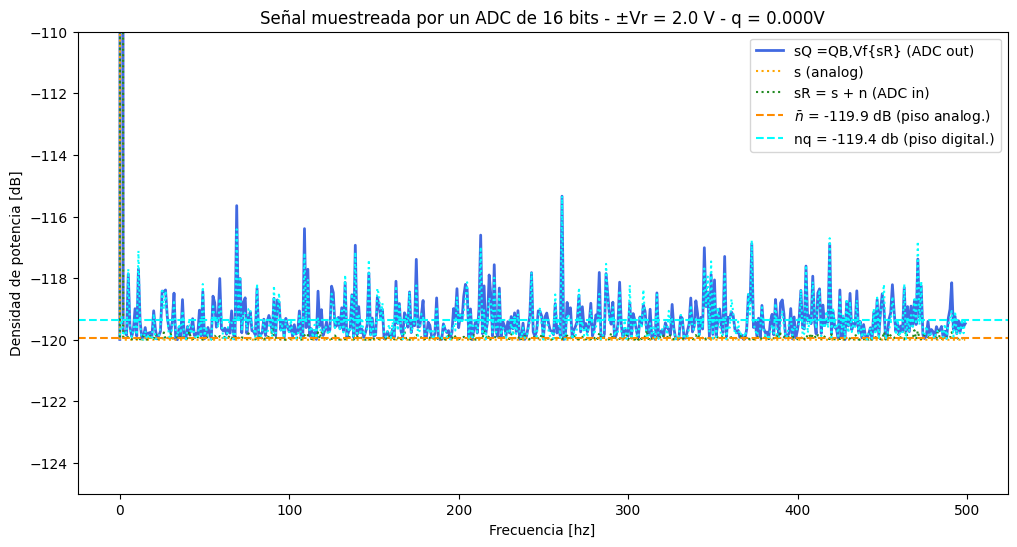

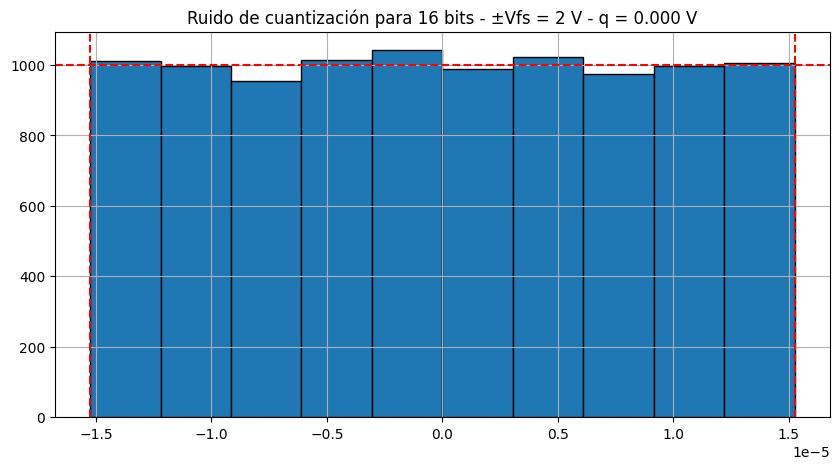

In [31]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

fs = 1000
N = 1000
A = np.sqrt(2)
vfs = 2 # Rango de tensión del ADC
B = 16   # Resolución del ADC [bits]
kn = 1/10  # Factor de escala del ruido analógico


def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
"tt: vector de tiempo , xx: vector de señal"

tt, xx = mi_funcion_sen(A , 0 , 1 , 0 , N , fs)

tt2, xx2 = mi_funcion_sen(A , 0 , 1 , 0 , N*10 , fs)

q = (vfs) / 2**B # Paso de cuantización
pq = (q**2)/12   # Potencia del ruido de cuantización
Pn = kn*pq       # Potencia del ruido analógico

snr_pn = 10 * np.log10(1/Pn) # SNR respecto al ruido analógico [dB]
ruido_pn = np.random.normal(0 , np.sqrt(Pn) , len(tt)) # Ruido analógico gaussiano de media 0 y desviación estándar sqrt(Pn)
ruido_pn2 = np.random.normal(0 , np.sqrt(Pn) , len(tt2))

#señal + ruido analógico (sR = s + n)
xxpn = xx + ruido_pn
xxpn2 = xx2 + ruido_pn2

# recorte al rango del ADC
xxpn_clip = np.clip(xxpn, -vfs, vfs)
xxpn_clip2 = np.clip(xxpn2, -vfs, vfs)

# cuantización
xxq = q * np.round(xxpn_clip / q)
xxq2 = q * np.round(xxpn_clip2 / q)

#error
eq = xxq - xxpn_clip
eq2 = xxq2 - xxpn_clip2

# GRÁFICO 1: Señal en el dominio del tiempo
plt.figure(figsize=(12,6))
plt.plot(tt, xxq, color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(tt, xxpn, '.:', color = 'forestgreen',label = 'sR = s + n (ADC in)')
plt.plot(tt, xx, '--', color = 'orange', label = 's (analog)', linewidth = 0.8)
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.show()

# Espectro de potencia
XX = np.fft.fft(xx)/N
XX_mod = 2 * (np.abs(XX)**2)

XXPn = np.fft.fft(xxpn)/N
XXPn_mod = 2 * (np.abs(XXPn)**2)

XXQ = np.fft.fft(xxq)/N
XXQ_mod = 2 * (np.abs(XXQ)**2)

EQ = np.fft.fft(eq)/N
EQ_mod = 2 * (np.abs(EQ)**2)

# Vector de frecuencias
freq = np.fft.fftfreq(len(xx), 1/fs)

# magnitud normalizada en dB
XX_db = 10 * np.log10(XX_mod + 1e-12)
XXPn_db = 10 * np.log10(XXPn_mod + 1e-12)
XXQ_db = 10 * np.log10(XXQ_mod + 1e-12)
EQ_db = 10 * np.log10(EQ_mod + 1e-12)

piso_analog = 10 * np.log10(Pn/(N/2) + 1e-12)
print(f'Piso analógico: {piso_analog:.6f}')
piso_digital = 10 * np.log10(pq/(N/2) + 1e-12)
print(f'Piso digital: {piso_digital:.6f}')


# GRÁFICO 2: Densidad de potencia espectral
plt.figure(figsize=(12,6))
#plt.ylim(-83, 10)

N_half = N // 2
freq_pos = freq[:N_half]

bin_senal = np.argmax(XXPn_mod[:N_half])  # índice del pico
mask_ruido = np.ones(N_half, dtype=bool)
mask_ruido[bin_senal] = False             # excluís el pico

piso_analog_medido  = 10 * np.log10(np.mean(XXPn_mod[:N_half][mask_ruido]) + 1e-12)
piso_digital_medido = 10 * np.log10(np.mean(EQ_mod[:N_half]) + 1e-12)

plt.plot(freq_pos, XXQ_db[:N_half], color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(freq_pos, XX_db[:N_half], ':', color = 'orange', label = 's (analog)', linewidth = 1.5)
plt.plot(freq_pos, XXPn_db[:N_half], ':', color = 'forestgreen',label = 'sR = s + n (ADC in)', linewidth = 1.5)
plt.axhline(piso_analog_medido, color = 'darkorange', linestyle='--', label = f'$\\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)',linewidth = 1.5)
plt.axhline(piso_digital_medido, color = 'cyan', linestyle='--', label = f'nq = {piso_digital:.1f} db (piso digital.)', linewidth = 1.5)
plt.plot(freq_pos, EQ_db[:N_half], ':', color='cyan')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("Frecuencia [hz]")
plt.ylabel("Densidad de potencia [dB]")
plt.legend()
plt.show()

# GRÁFICO 2: Densidad de potencia espectral
plt.figure(figsize=(12,6))
plt.ylim(-125, -110)

N_half = N // 2
freq_pos = freq[:N_half]

bin_senal = np.argmax(XXPn_mod[:N_half])  # índice del pico
mask_ruido = np.ones(N_half, dtype=bool)
mask_ruido[bin_senal] = False             # excluís el pico

piso_analog_medido  = 10 * np.log10(np.mean(XXPn_mod[:N_half][mask_ruido]) + 1e-12)
piso_digital_medido = 10 * np.log10(np.mean(EQ_mod[:N_half]) + 1e-12)

plt.plot(freq_pos, XXQ_db[:N_half], color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(freq_pos, XX_db[:N_half], ':', color = 'orange', label = 's (analog)', linewidth = 1.5)
plt.plot(freq_pos, XXPn_db[:N_half], ':', color = 'forestgreen',label = 'sR = s + n (ADC in)', linewidth = 1.5)
plt.axhline(piso_analog_medido, color = 'darkorange', linestyle='--', label = f'$\\bar{{n}}$ = {piso_analog:.1f} dB (piso analog.)',linewidth = 1.5)
plt.axhline(piso_digital_medido, color = 'cyan', linestyle='--', label = f'nq = {piso_digital:.1f} db (piso digital.)', linewidth = 1.5)
plt.plot(freq_pos, EQ_db[:N_half], ':', color='cyan')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("Frecuencia [hz]")
plt.ylabel("Densidad de potencia [dB]")
plt.legend()
plt.show()

# GRÁFICO 3: Histograma del error de cuantización
plt.figure(figsize=(10,5))

# histograma y guardo datos
counts, bins, _ = plt.hist(eq2, bins=10, edgecolor='black')

# centros de cada barra
centros = 0.5 * (bins[:-1] + bins[1:])

# barras dentro del intervalo [-q/2, q/2]
mask = (centros >= -q/2) & (centros <= q/2)

# media de las alturas en ese intervalo
media_intervalo = np.mean(counts[mask])

# líneas rojas
plt.axvline(-q/2, color='r', linestyle='--')
plt.axvline(q/2, color='r', linestyle='--')
plt.axhline(media_intervalo, color='r', linestyle='--')
plt.title(f'Ruido de cuantización para {B} bits - ±Vfs = {vfs} V - q = {q:.3f} V')
plt.grid(True)
plt.show()


Para esta cantidad de bits podemos observar cambios todavía más notables en el primer gráfico. En el segundo gráfico podemos ver que el piso analógico y el digital tienen valores muy parecidos, cercanos a -120dB, que es el limite de representación numérica de python.